In [1]:
import os
print(os.getcwd())

c:\Users\anami\OneDrive\Desktop\machine l


In [2]:
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [3]:
df = pd.read_csv("student/Student_survey.csv")
print(df.head())

           Timestamp  Registration Number  \
0  6/15/2026 9:25:39              2547231   
1  6/15/2026 9:53:54              2547237   
2  6/15/2026 9:54:56              2547203   
3  6/15/2026 9:55:17              2547228   
4  6/15/2026 9:55:42              2547241   

                                        Email  \
0       kunnal.kunnal@mca.christuniversity.in   
1  omkaar.chakraborty@mca.christuniversity.in   
2        abhinav.jain@mca.christuniversity.in   
3          jai.pareek@mca.christuniversity.in   
4             r.karan@mca.christuniversity.in   

   Job role that you are interested in  \
0  Software Development Engineer (SDE)   
1  Software Development Engineer (SDE)   
2                 Full Stack Developer   
3                 Full Stack Developer   
4  Software Development Engineer (SDE)   

  What is the minimum salary of students placed through campus (In LPA..respond as a number)  \
0                                                3.5                                 

Check Dataset Dimensions

In [4]:
print("Rows and Columns:", df.shape)

Rows and Columns: (50, 15)


Check Missing Values

In [5]:
print(df.isnull().sum())

Timestamp                                                                                     0
Registration Number                                                                           0
Email                                                                                         0
Job role that you are interested in                                                           0
What is the minimum salary of students placed through campus (In LPA..respond as a number)    0
What is the maximum salary of students placed through campus (In LPA..respond as a number)    0
What is the median salary of students placed through campus (In LPA..respond as a number)     0
Which is the highest paying company that recruits from campus?                                1
Rate your contribution towards extra curricular activities                                    1
Rate your technical competencies                                                              1
What are your package expectations (LPA)

Handle Null Values

In [6]:
df = df.dropna()

Convert Required Columns to Numeric

In [7]:
df["Your CIA % of last semester"] = pd.to_numeric(
    df["Your CIA % of last semester"],
    errors="coerce"
)

df["Your GPA of last semester"] = pd.to_numeric(
    df["Your GPA of last semester"],
    errors="coerce"
)

df["Your maximum attendance % till last semester"] = pd.to_numeric(
    df["Your maximum attendance % till last semester"],
    errors="coerce"
)

df = df.dropna()

Remove Duplicate Records

In [8]:
df = df.drop_duplicates()

print("Dataset Shape:", df.shape)

Dataset Shape: (37, 15)


Statistical Summary

In [9]:
print(df.describe())

       Registration Number  \
count         3.700000e+01   
mean          2.547231e+06   
std           1.733572e+01   
min           2.547201e+06   
25%           2.547218e+06   
50%           2.547232e+06   
75%           2.547242e+06   
max           2.547262e+06   

       Rate your contribution towards extra curricular activities  \
count                                          37.000000            
mean                                            3.405405            
std                                             1.279311            
min                                             1.000000            
25%                                             3.000000            
50%                                             4.000000            
75%                                             4.000000            
max                                             5.000000            

       Rate your technical competencies  Your CIA % of last semester  \
count                         37.00

Experiment 1: CIA % → GPA
Select Variables

In [10]:
X = df[["Your CIA % of last semester"]]
Y = df["Your GPA of last semester"]

Split Data

In [11]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42
)

Train Scikit-Learn Model

In [12]:
model = LinearRegression()

model.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Obtain Slope and Intercept

In [13]:
slope = model.coef_[0]
intercept = model.intercept_

print("Slope:", slope)
print("Intercept:", intercept)

Slope: 0.013667451028734224
Intercept: 2.4248375266702817


Prediction

In [14]:
y_pred = model.predict(X_test)

print(y_pred)

[3.28588694 3.24488459 3.3815591  3.408894   3.3815591  3.3815591
 3.4362289  3.39522655]


Calculate Slope Manually

In [15]:
x = df["Your CIA % of last semester"].values
y = df["Your GPA of last semester"].values

x_mean = np.mean(x)
y_mean = np.mean(y)

m = np.sum((x - x_mean)*(y - y_mean)) / np.sum((x - x_mean)**2)

b = y_mean - m*x_mean

print("Manual Slope:", m)
print("Manual Intercept:", b)

Manual Slope: 0.01421148864583287
Manual Intercept: 2.393904088220416


Manual Predictions

In [16]:
manual_pred = m * X_test.values.flatten() + b

print(manual_pred)

[3.28922787 3.24659341 3.38870829 3.41713127 3.38870829 3.38870829
 3.44555425 3.40291978]


Compare Outputs

In [17]:
comparison = pd.DataFrame({
    "Scikit Learn": y_pred,
    "Manual OLS": manual_pred
})

comparison["Difference"] = abs(
    comparison["Scikit Learn"] -
    comparison["Manual OLS"]
)

print(comparison.head())

   Scikit Learn  Manual OLS  Difference
0      3.285887    3.289228    0.003341
1      3.244885    3.246593    0.001709
2      3.381559    3.388708    0.007149
3      3.408894    3.417131    0.008237
4      3.381559    3.388708    0.007149


Experiment 2: Attendance % → GPA

In [18]:
X = df[["Your maximum attendance % till last semester"]]

Y = df["Your GPA of last semester"]

Save Parameters Using Pickle

In [19]:
parameters = {
    "slope": slope,
    "intercept": intercept
}

with open("linear_regression_weights.pkl", "wb") as file:
    pickle.dump(parameters, file)

print("Parameters Saved")

Parameters Saved


Load Parameters

In [21]:
with open("linear_regression_weights.pkl", "rb") as file:
    loaded_params = pickle.load(file)

print(loaded_params)

{'slope': np.float64(0.013667451028734224), 'intercept': np.float64(2.4248375266702817)}


Predict Using Loaded Parameters

In [22]:
m = loaded_params["slope"]
b = loaded_params["intercept"]

new_x = 85

prediction = m * new_x + b

print("Predicted GPA:", prediction)

Predicted GPA: 3.5865708641126908


CIA % vs GPA:

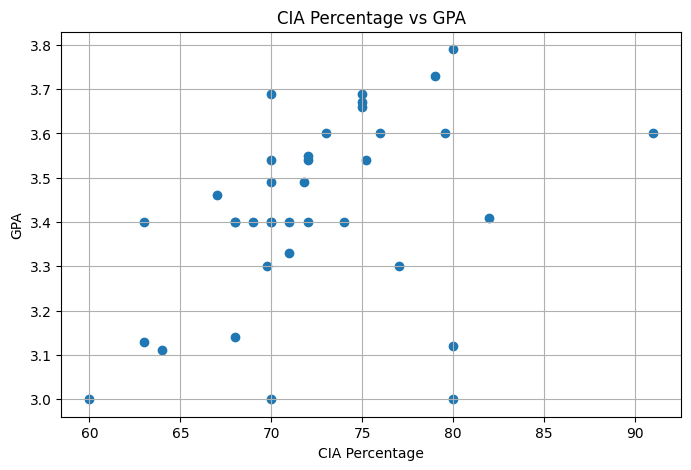

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df["Your CIA % of last semester"],
            df["Your GPA of last semester"])

plt.xlabel("CIA Percentage")
plt.ylabel("GPA")
plt.title("CIA Percentage vs GPA")
plt.grid(True)
plt.show()

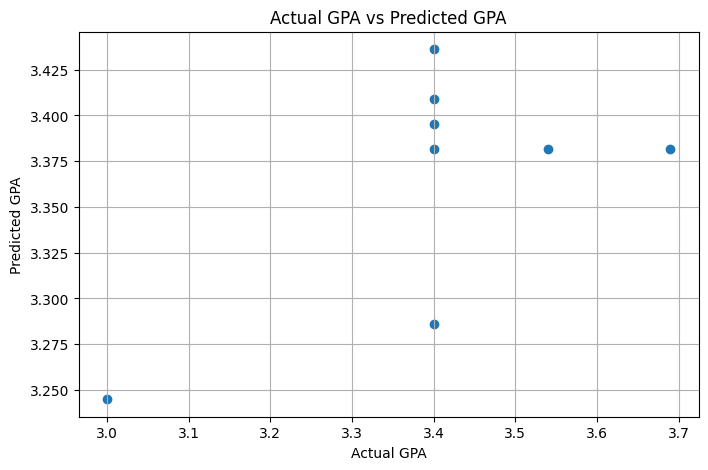

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(Y_test, y_pred)

plt.xlabel("Actual GPA")
plt.ylabel("Predicted GPA")
plt.title("Actual GPA vs Predicted GPA")

plt.grid(True)
plt.show()